In [43]:
# Importing standard packages for data exploration and processing.
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
pd.set_option("display.max_rows", 20)
pd.set_option("display.max_columns", 20)

In [44]:
players_match = pd.read_csv('players_match.csv')
players_match.head()

,Profile,Season_id,Team_id,Match_id,Team,Home_team,Winner,Home,Win
0,https://en.khl.ru/players/16673/,244,54,6993,Amur,Barys,Barys,0,1
1,https://en.khl.ru/players/16673/,244,54,7869,Amur,Amur,Amur,1,1
2,https://en.khl.ru/players/16673/,244,54,9037,Amur,Amur,SKA,1,0
3,https://en.khl.ru/players/16673/,244,54,9701,Amur,Amur,Atlant,1,0
4,https://en.khl.ru/players/16673/,244,54,10343,Amur,Amur,Severstal,1,0


In [4]:
# Some columns have already served their purpose and some need to be objects to get dummies.
players_match = players_match.drop(['Team', 'Home_team', 'Winner', 'Win'], axis=1)
list_objects = ['Profile', 'Season_id', 'Team_id', 'Match_id']
players_match[list_objects] = players_match[list_objects].astype('string')
players_match.head()

,Profile,Season_id,Team_id,Match_id,Home
0,https://en.khl.ru/players/16673/,244,54,6993,0
1,https://en.khl.ru/players/16673/,244,54,7869,1
2,https://en.khl.ru/players/16673/,244,54,9037,1
3,https://en.khl.ru/players/16673/,244,54,9701,1
4,https://en.khl.ru/players/16673/,244,54,10343,1


In [5]:
players_match.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 422943 entries, 0 to 422942
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Profile    422943 non-null  string
 1   Season_id  422943 non-null  string
 2   Team_id    422943 non-null  string
 3   Match_id   422943 non-null  string
 4   Home       422943 non-null  int64 
dtypes: int64(1), string(4)
memory usage: 16.1 MB


We can add extra columns to capture the interaction between already existing ones.

In [6]:
players_match['Profile|season'] = players_match['Profile'] + '|' + players_match['Season_id']
# players_match['Profile|team'] = players_match['Profile'] + '|' + players_match['Team_id']
# players_match['Season|team'] = players_match['Season_id'] + '|' + players_match['Team_id']
players_match.head()

,Profile,Season_id,Team_id,Match_id,Home,Profile|season
0,https://en.khl.ru/players/16673/,244,54,6993,0,https://en.khl.ru/players/16673/|244
1,https://en.khl.ru/players/16673/,244,54,7869,1,https://en.khl.ru/players/16673/|244
2,https://en.khl.ru/players/16673/,244,54,9037,1,https://en.khl.ru/players/16673/|244
3,https://en.khl.ru/players/16673/,244,54,9701,1,https://en.khl.ru/players/16673/|244
4,https://en.khl.ru/players/16673/,244,54,10343,1,https://en.khl.ru/players/16673/|244


In [7]:
players_match = players_match.drop('Profile', axis=1)
players_match.head()

,Season_id,Team_id,Match_id,Home,Profile|season
0,244,54,6993,0,https://en.khl.ru/players/16673/|244
1,244,54,7869,1,https://en.khl.ru/players/16673/|244
2,244,54,9037,1,https://en.khl.ru/players/16673/|244
3,244,54,9701,1,https://en.khl.ru/players/16673/|244
4,244,54,10343,1,https://en.khl.ru/players/16673/|244


In [9]:
# Careful not to get the match ID dummies.
# We are getting the dummies as floats so that we can have negative values for the dummies of the away team.
list_dummies = [col for col in players_match if col not in ['Match_id', 'Home']]
# players_dummies = pd.get_dummies(data=players_match, columns=list_dummies, dtype='float16')
players_match = pd.get_dummies(data=players_match, columns=list_dummies)
players_match.head()

NameError: name 'players_dummies' is not defined

In [13]:
home = players_match[players_match['Home'] == 1].drop('Home', axis=1)

In [14]:
away = players_match[players_match['Home'] == 0].drop('Home', axis=1)

In [15]:
home.head()

,Match_id,Season_id_1045,Season_id_1046,Season_id_160,Season_id_165,Season_id_167,Season_id_168,Season_id_185,Season_id_186,Season_id_202,...,Profile|season_https://en.khl.ru/players/99/|203,Profile|season_https://en.khl.ru/players/99/|222,Profile|season_https://en.khl.ru/players/99/|244,Profile|season_https://en.khl.ru/players/99/|245,Profile|season_https://en.khl.ru/players/99/|266,Profile|season_https://en.khl.ru/players/99/|267,Profile|season_https://en.khl.ru/players/99/|309,Profile|season_https://en.khl.ru/players/99/|310,Profile|season_https://en.khl.ru/players/99/|405,Profile|season_https://en.khl.ru/players/99/|468
1,7869,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,9037,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,9701,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,10343,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,5154,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [17]:
len(home)

211387

In [18]:
len(away)

211556

In [19]:
del players_match

In [20]:
import gc

gc.collect()

6650

In [21]:
home = home.groupby('Match_id').max()

In [22]:
away = away.groupby('Match_id').max()

In [23]:
home.head()

,Season_id_1045,Season_id_1046,Season_id_160,Season_id_165,Season_id_167,Season_id_168,Season_id_185,Season_id_186,Season_id_202,Season_id_203,...,Profile|season_https://en.khl.ru/players/99/|203,Profile|season_https://en.khl.ru/players/99/|222,Profile|season_https://en.khl.ru/players/99/|244,Profile|season_https://en.khl.ru/players/99/|245,Profile|season_https://en.khl.ru/players/99/|266,Profile|season_https://en.khl.ru/players/99/|267,Profile|season_https://en.khl.ru/players/99/|309,Profile|season_https://en.khl.ru/players/99/|310,Profile|season_https://en.khl.ru/players/99/|405,Profile|season_https://en.khl.ru/players/99/|468
Match_id,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
100,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1000,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10000,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [24]:
home.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10505 entries, 1 to 9999
Columns: 16561 entries, Season_id_1045 to Profile|season_https://en.khl.ru/players/99/|468
dtypes: uint8(16561)
memory usage: 166.0+ MB


In [25]:
home = home.astype('float16')
away = away.astype('float16')

In [27]:
home.head()

,Season_id_1045,Season_id_1046,Season_id_160,Season_id_165,Season_id_167,Season_id_168,Season_id_185,Season_id_186,Season_id_202,Season_id_203,...,Profile|season_https://en.khl.ru/players/99/|203,Profile|season_https://en.khl.ru/players/99/|222,Profile|season_https://en.khl.ru/players/99/|244,Profile|season_https://en.khl.ru/players/99/|245,Profile|season_https://en.khl.ru/players/99/|266,Profile|season_https://en.khl.ru/players/99/|267,Profile|season_https://en.khl.ru/players/99/|309,Profile|season_https://en.khl.ru/players/99/|310,Profile|season_https://en.khl.ru/players/99/|405,Profile|season_https://en.khl.ru/players/99/|468
Match_id,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
100,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [26]:
home.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10505 entries, 1 to 9999
Columns: 16561 entries, Season_id_1045 to Profile|season_https://en.khl.ru/players/99/|468
dtypes: float16(16561)
memory usage: 331.9+ MB


In [29]:
# The season ID dummies should not be subtracted as that would turn all of them into zeros.
columns_diff = [col for col in home if not col.startswith('Season')]
match = home.copy()
match[columns_diff] = match[columns_diff] - away[columns_diff]

In [30]:
match.head()

,Season_id_1045,Season_id_1046,Season_id_160,Season_id_165,Season_id_167,Season_id_168,Season_id_185,Season_id_186,Season_id_202,Season_id_203,...,Profile|season_https://en.khl.ru/players/99/|203,Profile|season_https://en.khl.ru/players/99/|222,Profile|season_https://en.khl.ru/players/99/|244,Profile|season_https://en.khl.ru/players/99/|245,Profile|season_https://en.khl.ru/players/99/|266,Profile|season_https://en.khl.ru/players/99/|267,Profile|season_https://en.khl.ru/players/99/|309,Profile|season_https://en.khl.ru/players/99/|310,Profile|season_https://en.khl.ru/players/99/|405,Profile|season_https://en.khl.ru/players/99/|468
Match_id,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
100,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [31]:
match.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10505 entries, 1 to 9999
Columns: 16561 entries, Season_id_1045 to Profile|season_https://en.khl.ru/players/99/|468
dtypes: float16(16561)
memory usage: 331.9+ MB


In [32]:
match.describe()

,Season_id_1045,Season_id_1046,Season_id_160,Season_id_165,Season_id_167,Season_id_168,Season_id_185,Season_id_186,Season_id_202,Season_id_203,...,Profile|season_https://en.khl.ru/players/99/|203,Profile|season_https://en.khl.ru/players/99/|222,Profile|season_https://en.khl.ru/players/99/|244,Profile|season_https://en.khl.ru/players/99/|245,Profile|season_https://en.khl.ru/players/99/|266,Profile|season_https://en.khl.ru/players/99/|267,Profile|season_https://en.khl.ru/players/99/|309,Profile|season_https://en.khl.ru/players/99/|310,Profile|season_https://en.khl.ru/players/99/|405,Profile|season_https://en.khl.ru/players/99/|468
count,10505.000000,10505.000000,10505.000000,10505.000000,10505.000000,10505.000000,10505.000000,10505.000000,10505.000000,10505.000000,...,10505.000000,10505.000000,10505.000000,10505.000000,10505.000000,10505.000000,10505.000000,10505.000000,10505.000000,10505.000000
mean,0.065125,0.007519,0.063965,0.005806,0.063904,0.006855,0.059113,0.008186,0.059113,0.007904,...,-0.000095,0.000762,-0.000476,-0.000095,0.000190,-0.000095,-0.000286,0.000000,0.001238,0.000381
std,0.246826,0.086426,0.244751,0.075989,0.244507,0.082520,0.235840,0.090149,0.235840,0.088562,...,0.032349,0.051636,0.066895,0.025818,0.072998,0.021820,0.069641,0.019516,0.054291,0.051605
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [33]:
# Cleaning up the memory.
del away
gc.collect()

15

Let us play around with the resulting data a bit.

In [35]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(match, wins.values.ravel(), test_size=0.3, random_state=42)

In [46]:
from sklearn.linear_model import LogisticRegression

# Logistic regression has a big advantage of being able to calculate probabilities rather than just predict the outcome.
# After all, it is already common knowledge that a stronger team would be more likely to win than a weaker one.
model = LogisticRegression(max_iter=1000, n_jobs=-1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [37]:
from sklearn.metrics import classification_report, plot_confusion_matrix

In [38]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.46      0.40      0.43      1428
           1       0.55      0.60      0.58      1724

    accuracy                           0.51      3152
   macro avg       0.51      0.50      0.50      3152
weighted avg       0.51      0.51      0.51      3152



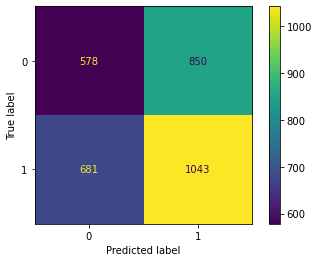

In [39]:
plot_confusion_matrix(model, X_test, y_test)

It is interesting how the model actually mislabeles the winning matches for the home team less often than expected, yet mislabeles the losing matches quite often. But again, the low accuracy was to be expected - after all, we are missing some key components. We only have one dummy variable per player, so they are expected to have a kind of average performance of that player over all his (potentially many) years of playing in KHL.

The easiest way to fix that would be adding an extra set of columns conditional on the player and the seasons ID. That would turn the player's performance into an average over a specific season and should significantly improve the model. We could also add the same kind of interractions between all other variables such as player-team and team-season.

Ideally, we would even want to create dummies for player-player interactions, capturing the synergy between them. However, that would create a number of features equal to the number of players to power of 2 (around 10 million) and even after dropping the all-null columns (since most of the players have probably only played with a few dozen or hundred players) it could still leave us in the ballpark of several hundred thousand features. Not only is such a model extremely prone to overfitting but it is also very computationally heavy.

This is why we cannot use the polynomial features from sklearn as they would quickly get out of control, and have to do it manually.